# 【notebook｜N-11】价值头与校准（scalar vs 64-bin）
> 对应：《04-价值头/01-价值头原理.md》【文档｜DOC-VH】；代码 `F-b04-value_head`、`F-b04-train_value_head`

**对应理论**：`04-价值头/01-价值头原理.md`

**对应 AlphaProof 源码**：
- `reap-new-update-model/app/value_head.py`（`ValueHead`、`proof_depth_to_target`）
- `v1-1-agentic-tool/gpu/gpu_runtime/categorical_search_backend.py`（two-hot + 交叉熵）
- `reap-new-update-model-value-head/nanoproof/nanoproof/inference.py`（`<|bin_XX|>` 解码）

**Colab 运行说明**：本 notebook 自带全部实现，只依赖 torch + matplotlib（CPU 即可），
点“全部运行”约 1 分钟；有 GPU 会自动加速。

In [1]:
# 【N-11.c1】
import math, random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0); random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| torch:", torch.__version__)

device: cuda | torch: 2.12.0+git6bbd260


## 1. 目标变换（对照 `app/value_head.py`）

- 折扣回报 `G_t = r_t + gamma * G_{t+1}`，裁剪到 `[-1,1]`；
- 剩余深度 `target(d) = -min(d,64)/64`（终止=0，最深=-1）；
- two-hot：小数距离投到相邻两桶，桶 64 饱和。

In [2]:
# 【N-11.c2】
def discounted_returns(rewards, gamma=0.99):
    out = [0.0] * len(rewards); running = 0.0
    for i in range(len(rewards) - 1, -1, -1):
        running = rewards[i] + gamma * running
        out[i] = max(-1.0, min(1.0, running))
    return out

def proof_depth_to_target(depth, max_depth=64):
    return -min(float(depth), float(max_depth)) / float(max_depth)

def distance_two_hot(distance, num_bins=64):
    clipped = min(float(distance), float(num_bins))
    lower, upper = math.floor(clipped), math.ceil(clipped)
    w_up = clipped - lower; w_lo = 1.0 - w_up
    w = torch.zeros(num_bins); w[lower - 1] += w_lo
    if w_up: w[upper - 1] += w_up
    return w

print("discounted_returns([0,0,1], 0.9) =", [round(x,3) for x in discounted_returns([0,0,1],0.9)])
print("proof_depth_to_target(0,64) =", proof_depth_to_target(0))
print("proof_depth_to_target(7,64) =", round(proof_depth_to_target(7), 4))
print("proof_depth_to_target(999,64) =", proof_depth_to_target(999))
w = distance_two_hot(3.4)
print("two-hot(3.4) 非零桶:", [(i+1, round(float(w[i]),3)) for i in range(64) if w[i] > 0])
print("two-hot 期望 =", round(float((w * torch.arange(1,65)).sum()), 4))

discounted_returns([0,0,1], 0.9) = [0.81, 0.9, 1.0]
proof_depth_to_target(0,64) = -0.0
proof_depth_to_target(7,64) = -0.1094
proof_depth_to_target(999,64) = -1.0
two-hot(3.4) 非零桶: [(3, 0.6), (4, 0.4)]
two-hot 期望 = 3.4


## 2. 两种价值头与训练（合成特征便于 CPU 快速演示）

真实场景是 3584 维 cached hidden state；这里用 64 维合成特征，前 8 维决定剩余深度。

In [3]:
# 【N-11.c3】
H, N = 64, 3000

def synthetic(n, hidden=H, seed=0, max_depth=64):
    g = torch.Generator().manual_seed(seed)
    z = torch.randn(n, hidden, generator=g)
    sig = torch.randn(n, 8, generator=g)
    depth = torch.clamp((sig.norm(dim=1) * 6).round().long(), 0, max_depth)
    z[:, :8] = sig
    return z, depth

x, depth = synthetic(N)
x, depth = x.to(device), depth.to(device)
y_scalar = (-depth.float() / 64.0).to(device)
dist = torch.clamp(depth.float(), min=1.0).to(device)
print("features", tuple(x.shape), "| depth mean", round(float(depth.float().mean()),2),
      "| min/max", int(depth.min()), int(depth.max()))

class ScalarHead(nn.Module):
    def __init__(self, h, hd=256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(h,hd), nn.SiLU(), nn.Linear(hd,1), nn.Tanh())
    def forward(self, z): return self.net(z.float()).squeeze(-1)

class CategoricalHead(nn.Module):
    def __init__(self, h, hd=256, bins=64):
        super().__init__()
        self.bins = bins
        self.net = nn.Sequential(nn.Linear(h,hd), nn.SiLU(), nn.Linear(hd,bins))
    def forward(self, z): return self.net(z.float())

def expected_distance(logits):
    p = torch.softmax(logits, -1)
    sup = torch.arange(1, logits.shape[-1] + 1, device=logits.device, dtype=p.dtype)
    return (p * sup).sum(-1)

def train_scalar(steps=600, bs=128, lr=1e-3):
    head = ScalarHead(H).to(device); opt = torch.optim.AdamW(head.parameters(), lr=lr)
    for s in range(steps):
        idx = torch.randint(0, N, (bs,), device=device)
        loss = F.mse_loss(head(x[idx]), y_scalar[idx])
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    return head, float(loss)

def train_cat(steps=600, bs=128, lr=1e-3):
    head = CategoricalHead(H).to(device); opt = torch.optim.AdamW(head.parameters(), lr=lr)
    for s in range(steps):
        idx = torch.randint(0, N, (bs,), device=device)
        logits = head(x[idx])
        tgt = torch.stack([distance_two_hot(float(d), 64) for d in dist[idx]]).to(device)
        loss = -(tgt * F.log_softmax(logits, -1)).sum(-1).mean()
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    return head, float(loss)

shead, s_loss = train_scalar()
chead, c_loss = train_cat()
with torch.no_grad():
    sp = shead(x); cd = expected_distance(chead(x))
print("scalar MSE:", round(s_loss,4), "| categorical CE:", round(c_loss,4))
print("scalar MAE(value):", round(float((sp - y_scalar).abs().mean()),4))
print("cat MAE(distance):", round(float((cd - dist).abs().mean()),4))

features (3000, 64) | depth mean 16.48 | min/max 5 34


/tmp/ipykernel_15740/959532284.py:42: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /app/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  return head, float(loss)


scalar MSE: 0.0002 | categorical CE: 1.8699
scalar MAE(value): 0.0125
cat MAE(distance): 2.8099


## 3. 校准：reliability diagram 与 ECE

把预测按等宽分箱，比较箱内平均预测与平均真实值；ECE 越小越校准。

ECE scalar = 0.0019
ECE categorical(conf) = 0.1947


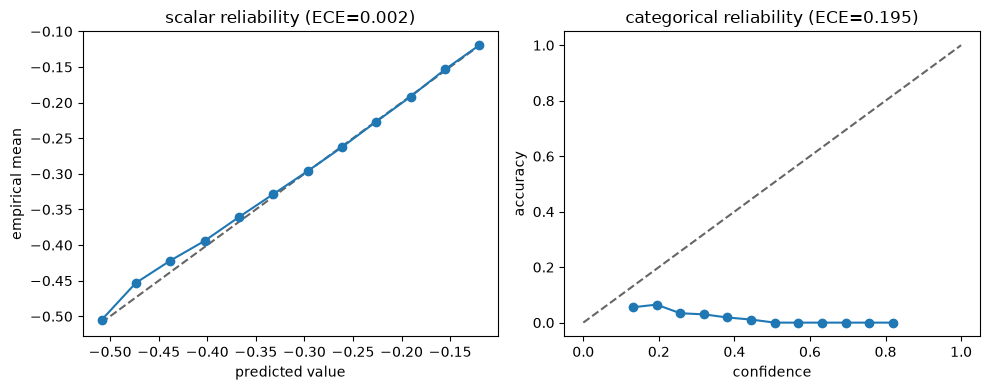

In [4]:
# 【N-11.c4】
def reliability(pred, target, n_bins=12):
    p = pred.detach().reshape(-1).float(); y = target.detach().reshape(-1).float()
    lo, hi = float(p.min()), float(p.max())
    if hi - lo < 1e-9: hi = lo + 1e-6
    edges = torch.linspace(lo, hi, n_bins + 1)
    centers, emp, ece = [], [], 0.0; n = p.numel()
    for b in range(n_bins):
        m = (p >= edges[b]) & (p <= edges[b+1]) if b == n_bins-1 else (p >= edges[b]) & (p < edges[b+1])
        c = int(m.sum()); centers.append(float((edges[b]+edges[b+1])/2))
        if c == 0: emp.append(float("nan")); continue
        e = float(y[m].mean()); emp.append(e); ece += c/n * abs(centers[-1]-e)
    return centers, emp, ece

with torch.no_grad(): sp = shead(x)
cs, es, ece_s = reliability(sp, y_scalar)
with torch.no_grad():
    probs = torch.softmax(chead(x), -1); conf, pred_bin = probs.max(-1)
correct = (torch.clamp(dist.round(), 1, 64).long() == pred_bin).float()
cb, eb, ece_c = reliability(conf, correct)
print("ECE scalar =", round(ece_s,4))
print("ECE categorical(conf) =", round(ece_c,4))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot([min(cs), max(cs)], [min(cs), max(cs)], "k--", alpha=.6)
ax[0].plot(cs, es, "o-"); ax[0].set_title(f"scalar reliability (ECE={ece_s:.3f})")
ax[0].set_xlabel("predicted value"); ax[0].set_ylabel("empirical mean")
ax[1].plot([0,1],[0,1], "k--", alpha=.6)
ax[1].plot(cb, eb, "o-"); ax[1].set_title(f"categorical reliability (ECE={ece_c:.3f})")
ax[1].set_xlabel("confidence"); ax[1].set_ylabel("accuracy")
plt.tight_layout(); plt.show()

## 4. `depth -> predicted value` 曲线（应单调下降）

scalar depth->value   : [(8, -0.145), (12, -0.195), (16, -0.248), (20, -0.31), (24, -0.377), (28, -0.453)] ...
cat    depth->distance: [(8, 14.66), (12, 15.9), (16, 16.37), (20, 17.3), (24, 17.91), (28, 20.23)] ...


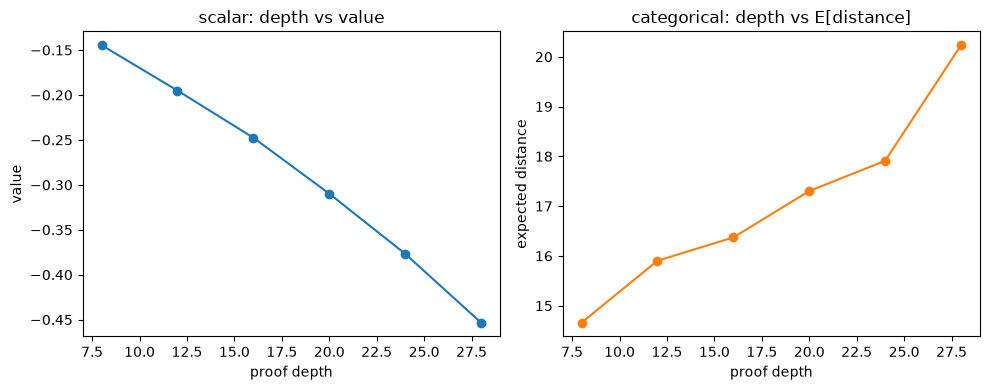

In [5]:
# 【N-11.c5】
s_curve, c_curve = [], []
for d in range(0, 65, 4):
    mask = depth == d
    if int(mask.sum()) < 5: continue
    with torch.no_grad():
        sv = float(shead(x[mask]).mean())
        cv = float(expected_distance(chead(x[mask])).mean())
    s_curve.append((d, sv)); c_curve.append((d, cv))
print("scalar depth->value   :", [(d, round(v,3)) for d,v in s_curve][:8], "...")
print("cat    depth->distance:", [(d, round(v,2)) for d,v in c_curve][:8], "...")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot([d for d,_ in s_curve], [v for _,v in s_curve], "o-")
ax[0].set_title("scalar: depth vs value"); ax[0].set_xlabel("proof depth"); ax[0].set_ylabel("value")
ax[1].plot([d for d,_ in c_curve], [v for _,v in c_curve], "o-", color="C1")
ax[1].set_title("categorical: depth vs E[distance]")
ax[1].set_xlabel("proof depth"); ax[1].set_ylabel("expected distance")
plt.tight_layout(); plt.show()

## 5. 改动实验（自己动手）

1. **容量**：把 `hd` 从 256 改成 32 / 512，比较拟合与 ECE；
2. **one-hot vs two-hot**：two-hot 换成四舍五入的 one-hot，观察 `depth->distance` 是否出现台阶；
3. **温度缩放**：对分类头学一个温度 `T`（最小化 NLL），比较 ECE 前后；
4. **饱和偏差**：把 `max_depth` 改成 16，观察桶饱和对深状态预测的影响。

In [6]:
# 【N-11.c6】
# 实验 3 参考：分类头温度缩放
logits = chead(x).detach()
labels = torch.clamp(dist.round(), 1, 64).long().to(logits.device)
log_T = torch.zeros(1, device=logits.device, requires_grad=True)
optT = torch.optim.LBFGS([log_T], lr=0.1, max_iter=100)
def _cl():
    optT.zero_grad()
    loss = F.cross_entropy(logits / log_T.exp(), labels)
    loss.backward(); return loss
optT.step(_cl)
print("learned temperature T =", round(float(log_T.exp()), 4))

learned temperature T = 2.1024
